## Linearly separable data

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate 2 clear clusters with a large separation (random_state ensures reproducibility)
X_hard, y_hard = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=2)

# Practice Goal: Train an SVC with a very high penalty (C=1e10) to force a hard margin
# from sklearn.svm import SVC
# clf = SVC(kernel='linear', C=1e10).fit(X_hard, y_hard)

In [13]:
X_hard.shape

(100, 2)

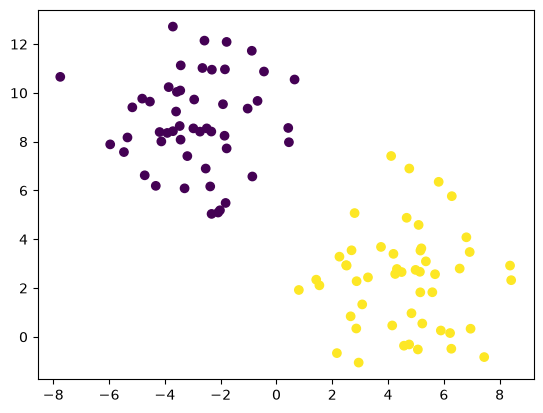

In [17]:
plt.scatter(x=X_hard[:,0], y=X_hard[:,1], c=y_hard)

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_hard, y_hard, test_size=0.2, random_state=42)

In [51]:
sv = SVC(kernel='rbf') #kernel : {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} 

In [52]:
sv.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [53]:
y_pred = sv.predict(X_test)

In [54]:
accuracy_score(y_test, y_pred)

1.0

<Axes: >

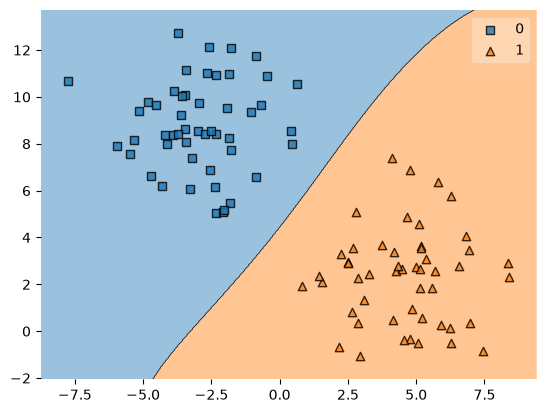

In [55]:
plot_decision_regions(X_hard, y_hard, clf=sv)

## Linearly Separable with Noise

In [72]:
# Generate overlapping clusters by increasing the standard deviation (cluster_std)
X_soft, y_soft = make_blobs(n_samples=150, centers=2, random_state=2, cluster_std=3)

# Practice Goal: Experiment with the regularization parameter 'C'. 
# A small C (e.g., C=0.1) creates a wider, softer margin. A larger C (e.g., C=10) hardens it.
# clf_soft = SVC(kernel='linear', C=0.1).fit(X_soft, y_soft)


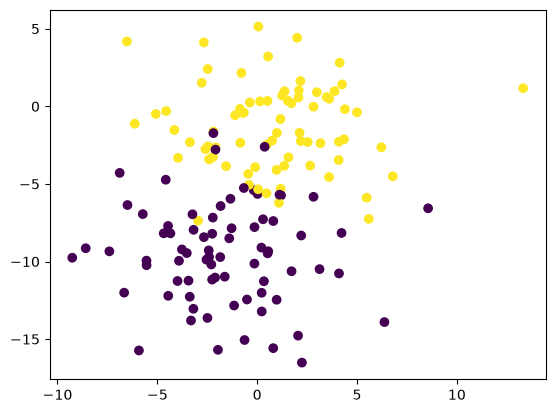

In [73]:
plt.scatter(x=X_soft[:,0], y=X_soft[:,1], c=y_soft)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X_soft, y_soft, test_size=0.2, random_state=42)

In [75]:
sv = SVC()
sv.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [76]:
y_pred = sv.predict(X_test)

In [77]:
accuracy_score(y_test, y_pred)

0.9

<Axes: >

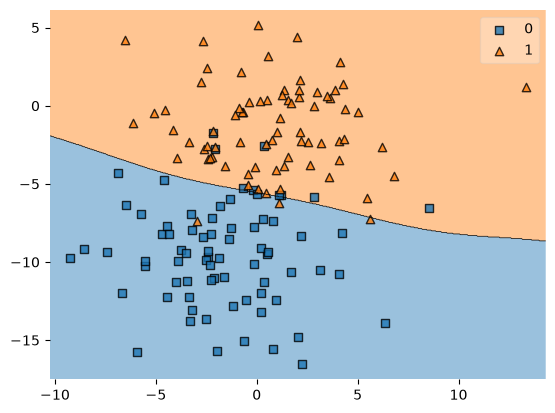

In [78]:
plot_decision_regions(X_soft, y_soft, clf=sv)

## a

In [80]:
from sklearn.datasets import make_circles, make_moons

# Option A: Concentric Circles (Excellent for RBF kernel testing)
X_circle, y_circle = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42)

# Option B: Interlocking Moons (Excellent for Polynomial kernel testing)
X_moon, y_moon = make_moons(n_samples=200, noise=0.15, random_state=42)

# Practice Goal: Train using non-linear kernels
# clf_nonlinear = SVC(kernel='rbf', C=1, gamma='scale').fit(X_circle, y_circle)


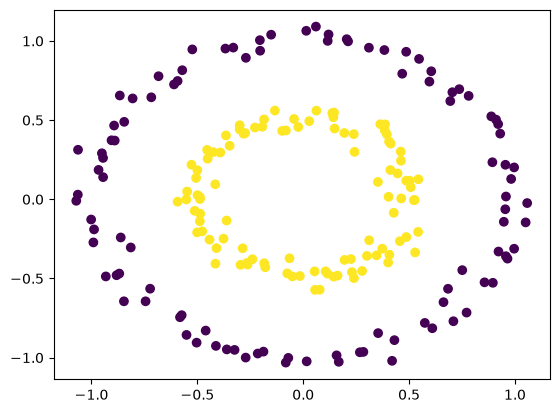

In [82]:
plt.scatter(x=X_circle[:,0], y=X_circle[:,1], c=y_circle)

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X_circle, y_circle, test_size=0.2, random_state=42)
sv.fit(X_train, y_train)
y_pred = sv.predict(X_test)
accuracy_score(y_test, y_pred)

1.0

<Axes: >

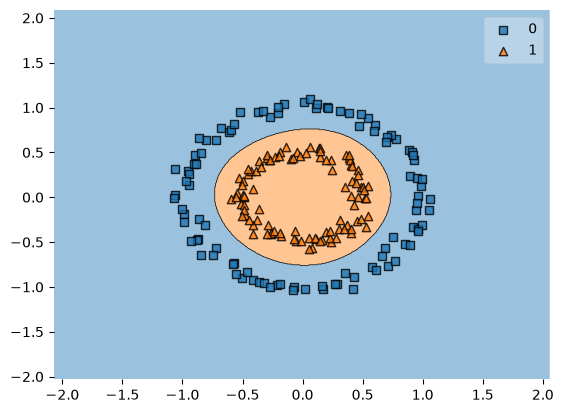

In [86]:
plot_decision_regions(X_circle, y_circle, clf=sv)